## Faster simulation with Ngspice shared library
Authored 1115/2024

In theory, there is a way to use the ngspice shared library to keep one circuit persistently loaded and remove redundant parsing, letting us vastly speed up simulations. 

Here, I try to make it viable and see if it actually speeds up the simulation.

In [155]:
%reload_ext autoreload
%autoreload 2

import PySpice.Spice.Xyce
import PySpice.Spice.Xyce.Server
from helpers import *
from spice_net import *

import numpy as np
import networkx as nx
import tqdm
import json
import matplotlib.pyplot as plt
import ltspice

import PySpice
PySpice.Spice.Simulation.CircuitSimulator.DEFAULT_SIMULATOR = "ngspice-shared" 
import PySpice.Spice.NgSpice.Server
PySpice.Spice.NgSpice.Server.SpiceServer.SPICE_COMMAND = 'ngspice'

In [156]:
# performance optimization to allow batching similar commands
def chunk_commands(cmds, MAX_LEN=1023):
    curr_chunk = ''
    for cmd in cmds:
        if len(curr_chunk) + len(cmd) > MAX_LEN:
            yield curr_chunk
            curr_chunk = ''
        curr_chunk += ';' + cmd
    yield curr_chunk

In [110]:
data = np.load("../data/xor_train_data_scale_1.0.npz")
inputs, outputs = data['inputs'], data['outputs'].astype(np.int64)

In [111]:
seed = 0
np.random.seed(seed)

grid_size = 4

grid_graph = nx.grid_graph([grid_size, grid_size], periodic=True)
# relabel nodes to be ints
grid_graph = nx.convert_node_labels_to_integers(grid_graph, first_label=1, ordering='sorted')
grid_graph.add_node(0)

# grid_graph.add_node((-1, -1))

for e in grid_graph.edges:
    # grid_graph[e[0]][e[1]]['weight'] = 0.5                           # init to max value
    grid_graph[e[0]][e[1]]['weight'] = np.random.uniform(0.1, 0.9)       # random value

node_cfg = (np.array([[6, 0], [8, 0], [16, 0], [14, 0]]), np.array([[11, 1]]))

net = TransistorNetwork('test', grid_graph, node_cfg, 'ngspice-shared')

In [112]:
simulator = net.cached_simulator

In [113]:
instance = simulator._ngspice_shared

In [114]:
net._prepare_simulation(inputs)

In [115]:
netlist_str = str(net) + ".op\n" + ".end\n"
print(netlist_str)


.title test
.subckt transistor_edge t_D t_S val=0.5
V1 t_G t_S {val}
R1 t_D t_S 1e+16
M1 t_D t_G t_S t_S Ideal
.ends transistor_edge
B1 6 0 v={pwl(V(index), 1, 0.11, 2, 0.11, 3, 0.11, 4, 0.11)}
B2 8 0 v={pwl(V(index), 1, 0.33000000000000007, 2, 0.33000000000000007, 3, 0.33000000000000007, 4, 0.33000000000000007)}
B3 16 0 v={pwl(V(index), 1, 0.0, 2, 0.0, 3, 0.44999999999999996, 4, 0.44999999999999996)}
B4 14 0 v={pwl(V(index), 1, 0.0, 2, 0.44999999999999996, 3, 0.0, 4, 0.44999999999999996)}
Vindex index 0 1
X1 1 5 transistor_edge val=0.5390508031418598
X2 1 13 transistor_edge val=0.6721514930979355
X3 1 2 transistor_edge val=0.5822107008573151
X4 1 4 transistor_edge val=0.5359065463975176
X5 2 6 transistor_edge val=0.4389238394711238
X6 2 14 transistor_edge val=0.6167152904533248
X7 2 3 transistor_edge val=0.45006976901015405
X8 3 7 transistor_edge val=0.8134184006256638
X9 3 15 transistor_edge val=0.8709302084008235
X10 3 4 transistor_edge val=0.40675321506062223
X11 4 8 transistor_edg

In [116]:
instance.ressource_usage()
instance.load_circuit(netlist_str)
instance.ressource_usage()

{'Total elapsed time (seconds)': 7822.297,
 'elapsed time since last call (seconds)': 0.459,
 'Total DRAM available': '16384.000 MB.',
 'DRAM currently available': '  32.000 MB.',
 'Maximum ngspice program size': '0 bytes.',
 'Current ngspice program size': ' 720.250 MB.',
 'Number of lines in the deck': 208,
 'Netlist loading time': 0.004,
 'Subckt and Param expansion time': 0.006,
 'Netlist parsing time': 0.005,
 'Nominal temperature': 27,
 'Operating temperature': 27,
 'Total iterations': 0,
 'Transient iterations': 0,
 'Circuit Equations': 50,
 'Circuit original non-zeroes': 0,
 'Circuit fill-in non-zeroes': 0,
 'Circuit total non-zeroes': 0,
 'Transient timepoints': 0,
 'Accepted timepoints': 0,
 'Rejected timepoints': 0,
 'Total analysis time (seconds)': 0,
 'Matrix load time': 0,
 'Matrix synchronize time': 0,
 'Matrix reorder time': 0,
 'Matrix factor time': 0,
 'Matrix solve time': 0,
 'Transient analysis time': 0,
 'Transient load time': 0,
 'Transient sync time': 0,
 'Transi

In [117]:
instance.exec_command('option klu')

''

In [118]:
print(instance.exec_command('run'))

Using KLU as Direct Linear Solver


Doing analysis at TEMP = 27.000000 and TNOM = 27.000000
Reference value :  0.00000e+00
No. of Data Rows : 1


In [119]:
print(instance.exec_command('set history = 10'))

In [120]:
# instance.exec_command('wrdata out.raw all') # dump everything in one line
instance.exec_command('write out.raw ' + ' '.join([f'v({i})' for i in range(len(net.nodes))]))

Error: no such vector 0
in term: v(0)


NgSpiceCommandError: Command 'write out.raw v(0) v(1) v(2) v(3) v(4) v(5) v(6) v(7) v(8) v(9) v(10) v(11) v(12) v(13) v(14) v(15) v(16) v(17)' failed

In [121]:
with open("out.raw", 'rb') as f:
    output = f.read()

binary_line = b'Binary:' + os.linesep.encode('ascii')
binary_location = output.find(binary_line)
if binary_location < 0:
    raise NameError('Cannot locate binary data')
raw_data_start = binary_location + len(binary_line)
# self._logger.debug(os.linesep + output[:raw_data_start].decode('utf-8'))
header_lines = output[:binary_location].splitlines()
raw_data = output[raw_data_start:]

In [122]:
raw_data

b'(\\\x8f\xc2\xf5(\xbc?\x9a\xdbxCS\xf9\xbf?\x14\xb11\xba\xa9I\xc0?\xee/;\xb3\xee\xc2\xc0?&\x8a\xefF\xe5)\xc1?\xbc\xf9\xf6\xa4o~\xc1?\x80\xadTl:(\xca?\x1e\x85\xebQ\xb8\x1e\xd5?\x16\x07{\xc3\n\xc1\xc5?|/\xcf<\x1b\x89\xc3?\xbc\xdd\xc5\xb1\xbe\xc9\xbd?8\x95\xeck\xae\xed\xb5?\xd0\xdd\xed:n\x00\xab?\x00\x00\x00\x00\x00\x00\x00\x00\xc0\xcd\xf8\xa6\x10)\x8c?\x00\x00\x00\x00\x00\x00\x00\x00\x88\xe6\x1cET\xfe\xa4?\xb8\x98\xbe\xdb\xa4\x1e\xac?D\x97\xf1C\xe0\xd8\xb0?\xb8\xdbK\'\xe8V\xb2?\xc6U\x14:\x8e\x9e\xb3?\x0e\x82\xf9\x1e\xec\xc2\xb4?\x08h*\x8fh\x1e\xb5?\x08\xc1\xaa8~\t\xb6?\xb07\xeew{_\xb6?\x1e,:\xbb\xc8\x1e\xb7?\xdcO\xb2`\xc5z\xb7?\xd8\x8b\xe1\xad\x86\xdc\xb7?`fn\xa9(+\xb8?`!T\xc9s\x9b\xb8?|w\x81`\xfa\xe6\xb8?\x10\x1d\xee6\xb6!\xb9?\x901[I\xadn\xb9?\x8a\x10lj\xd1\x0b\xba?P\x85\xcf\xb7\xf0;\xba?P[\xfd\xc1gt\xba?\x80%\xb0\xab\x86\xde\xba?\x10\xb5F\x07\xf1\x15\xbb?X\xf8lm L\xbb?\xc0\x16\xab\xb1\xb8\x8b\xbb?\xe0\x85\xe7\xc9\xc4\xcd\xbb?\x80\x7f.\xaa\xc8\x06\xbc?\xac\x05G/]\x9b\xbc?\xc4\x0f\x08\x

In [123]:
from PySpice.Spice.NgSpice.RawFile import RawFile


with open("out.raw", 'rb') as f:
    output = f.read()

raw_file = RawFile(output, 0)

NameError: Expected label Circuit instead of Date

In [124]:
instance.plot_names

['op279',
 'op278',
 'op277',
 'op276',
 'op275',
 'op274',
 'op273',
 'op272',
 'op271',
 'op270',
 'op269',
 'op268',
 'op267',
 'op266',
 'op265',
 'op264',
 'op263',
 'op262',
 'op261',
 'op260',
 'op259',
 'op258',
 'op257',
 'op256',
 'op255',
 'op254',
 'op253',
 'op252',
 'op251',
 'op250',
 'op249',
 'op248',
 'op247',
 'op246',
 'op245',
 'op244',
 'op243',
 'op242',
 'op241',
 'op240',
 'op239',
 'op238',
 'op237',
 'op236',
 'op235',
 'op234',
 'op233',
 'op232',
 'op231',
 'op230',
 'op229',
 'op228',
 'op227',
 'op226',
 'op225',
 'op224',
 'op223',
 'op222',
 'op221',
 'op220',
 'op219',
 'op218',
 'op217',
 'op216',
 'op215',
 'op214',
 'op213',
 'op212',
 'op211',
 'op210',
 'op209',
 'op208',
 'op207',
 'op206',
 'op205',
 'op204',
 'op203',
 'op202',
 'op201',
 'op200',
 'op199',
 'op198',
 'op197',
 'op196',
 'op195',
 'op194',
 'op193',
 'op192',
 'op191',
 'op190',
 'op189',
 'op188',
 'op187',
 'op186',
 'op185',
 'op184',
 'op183',
 'op182',
 'op181',
 'op180',


In [138]:
net.simulator()

In [139]:
instance.run()

Using SPARSE 1.3 as Direct Linear Solver


In [140]:
instance.plot_names

['op281',
 'op280',
 'op279',
 'op278',
 'op277',
 'op276',
 'op275',
 'op274',
 'op273',
 'op272',
 'op271',
 'op270',
 'op269',
 'op268',
 'op267',
 'op266',
 'op265',
 'op264',
 'op263',
 'op262',
 'op261',
 'op260',
 'op259',
 'op258',
 'op257',
 'op256',
 'op255',
 'op254',
 'op253',
 'op252',
 'op251',
 'op250',
 'op249',
 'op248',
 'op247',
 'op246',
 'op245',
 'op244',
 'op243',
 'op242',
 'op241',
 'op240',
 'op239',
 'op238',
 'op237',
 'op236',
 'op235',
 'op234',
 'op233',
 'op232',
 'op231',
 'op230',
 'op229',
 'op228',
 'op227',
 'op226',
 'op225',
 'op224',
 'op223',
 'op222',
 'op221',
 'op220',
 'op219',
 'op218',
 'op217',
 'op216',
 'op215',
 'op214',
 'op213',
 'op212',
 'op211',
 'op210',
 'op209',
 'op208',
 'op207',
 'op206',
 'op205',
 'op204',
 'op203',
 'op202',
 'op201',
 'op200',
 'op199',
 'op198',
 'op197',
 'op196',
 'op195',
 'op194',
 'op193',
 'op192',
 'op191',
 'op190',
 'op189',
 'op188',
 'op187',
 'op186',
 'op185',
 'op184',
 'op183',
 'op182',


In [137]:
res = instance.plot(net.simulator(), instance.last_plot).to_analysis()

In [129]:
res

In [130]:
print(instance.exec_command('print $history'))

10 = 1.000000e+01


In [81]:
print_cmds = [f'print v({e.edge.node_names[0]}) - v({e.edge.node_names[1]})' for e in net.edges]
for chunk in chunk_commands(print_cmds):
    print(instance.exec_command(chunk))

v(1) - v(51) = -9.25565e-04
v(1) - v(2451) = 7.671137e-04
v(1) - v(2) = -2.34986e-03
v(1) - v(50) = 2.534250e-03
v(2) - v(52) = -1.78909e-04
v(2) - v(2452) = 6.167267e-04
v(2) - v(3) = -3.70085e-03
v(3) - v(53) = -1.22789e-03
v(3) - v(2453) = 7.007812e-04
v(3) - v(4) = -3.14219e-03
v(4) - v(54) = -1.50240e-03
v(4) - v(2454) = 2.402087e-03
v(4) - v(5) = -2.57997e-03
v(5) - v(55) = -7.13555e-03
v(5) - v(2455) = 2.691434e-03
v(5) - v(6) = 2.667102e-02
v(6) - v(56) = -4.90812e-02
v(6) - v(2456) = -2.35648e-02
v(6) - v(7) = -9.43527e-02
v(7) - v(57) = 1.650080e-02
v(7) - v(2457) = 1.734808e-02
v(7) - v(8) = -1.25647e-01
v(8) - v(58) = 1.203665e-01
v(8) - v(2458) = 9.151063e-02
v(8) - v(9) = 1.600463e-01
v(9) - v(59) = 1.248156e-02
v(9) - v(2459) = -1.74597e-02
v(9) - v(10) = 1.733202e-02
v(10) - v(60) = 9.935904e-03
v(10) - v(2460) = -2.43501e-03
v(10) - v(11) = 3.626202e-02
v(11) - v(61) = -3.40525e-03
v(11) - v(2461) = -7.38662e-03
v(11) - v(12) = 3.070165e-02
v(12) - v(62) = 3.025988e-03

In [ ]:
instance.exec_command

In [66]:
print(instance.exec_command('print v(11) - v(1); print v(6) - v(1); print v(8) - v(1); print v(16) - v(1); print v(14) - v(1); print v(11) - v(6); print v(11) - v(8); print v(11) - v(16); print v(11) - v(14); print v(6) - v(8); print v(6) - v(16); print v(6) - v(14); print v(8) - v(16); print v(8) - v(14); print v(16) - v(14);'))

v(11) - v(1) = -8.53852e-03
v(6) - v(1) = -1.48982e-02
v(8) - v(1) = 2.051018e-01
v(16) - v(1) = -1.24898e-01
v(14) - v(1) = -1.24898e-01
v(11) - v(6) = 6.359633e-03
v(11) - v(8) = -2.13640e-01
v(11) - v(16) = 1.163596e-01
v(11) - v(14) = 1.163596e-01
v(6) - v(8) = -2.20000e-01
v(6) - v(16) = 1.100000e-01
v(6) - v(14) = 1.100000e-01
v(8) - v(16) = 3.300000e-01
v(8) - v(14) = 3.300000e-01
v(16) - v(14) = 0.000000e+00


In [60]:
for ss in 'print v(11) - v(1); print v(6) - v(1); print v(8) - v(1); print v(16) - v(1); print v(14) - v(1); print v(11) - v(6); print v(11) - v(8); print v(11) - v(16); print v(11) - v(14); print v(6) - v(8); print v(6) - v(16); print v(6) - v(14); print v(8) - v(16); print v(8) - v(14); print v(16) - v(14);'.split(';'):
    if ss:
        print(instance.exec_command(ss))


v(11) - v(1) = -8.53852e-03
v(6) - v(1) = -1.48982e-02
v(8) - v(1) = 2.051018e-01
v(16) - v(1) = -1.24898e-01
v(14) - v(1) = -1.24898e-01
v(11) - v(6) = 6.359633e-03
v(11) - v(8) = -2.13640e-01
v(11) - v(16) = 1.163596e-01
v(11) - v(14) = 1.163596e-01
v(6) - v(8) = -2.20000e-01
v(6) - v(16) = 1.100000e-01
v(6) - v(14) = 1.100000e-01
v(8) - v(16) = 3.300000e-01
v(8) - v(14) = 3.300000e-01
v(16) - v(14) = 0.000000e+00


In [20]:
i = 1
instance.exec_command(f'alter v.{net.edges[0].edge.name}.v1 dc = 2')

''

In [161]:
import tqdm.autonotebook


outs = []
instance.reset()
instance.destroy()
instance.exec_command('option klu')
instance.ressource_usage()

for _ in tqdm.autonotebook.trange(int(100000)):
    if _ % 100 == 0:
        instance.destroy()
    idx = np.random.randint(0, len(inputs))
    instance.exec_command(f'alter vindex dc = {idx}')
    res = instance.run()
    # outs.append(instance.exec_command('print v(11) - v(1)'))
    # res = instance.plot(net.simulator(), instance.plot_names[0]).to_analysis()

  0%|          | 0/100000 [00:00<?, ?it/s]

Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as D

In [159]:
instance.ressource_usage()

{'Total elapsed time (seconds)': 8280.972,
 'elapsed time since last call (seconds)': 30.873,
 'Total DRAM available': '16384.000 MB.',
 'DRAM currently available': '  38.438 MB.',
 'Maximum ngspice program size': '0 bytes.',
 'Current ngspice program size': ' 115.875 MB.',
 'Number of lines in the deck': 170,
 'Netlist loading time': 0,
 'Subckt and Param expansion time': 0.001,
 'Netlist parsing time': 0.001,
 'Nominal temperature': 27,
 'Operating temperature': 27,
 'Total iterations': 28121,
 'Transient iterations': 0,
 'Circuit Equations': 87,
 'Circuit original non-zeroes': 382,
 'Circuit fill-in non-zeroes': 10,
 'Circuit total non-zeroes': 392,
 'Transient timepoints': 0,
 'Accepted timepoints': 0,
 'Rejected timepoints': 0,
 'Total analysis time (seconds)': 8.093,
 'Matrix load time': 0.164,
 'Matrix synchronize time': 0,
 'Matrix reorder time': 0.114,
 'Matrix factor time': 0.075,
 'Matrix solve time': 0.039,
 'Transient analysis time': 0,
 'Transient load time': 0,
 'Transie

In [160]:
instance.plot_names

['op678',
 'op677',
 'op676',
 'op675',
 'op674',
 'op673',
 'op672',
 'op671',
 'op670',
 'op669',
 'op668',
 'op667',
 'op666',
 'op665',
 'op664',
 'op663',
 'op662',
 'op661',
 'op660',
 'op659',
 'op658',
 'op657',
 'op656',
 'op655',
 'op654',
 'op653',
 'op652',
 'op651',
 'op650',
 'op649',
 'op648',
 'op647',
 'op646',
 'op645',
 'op644',
 'op643',
 'op642',
 'op641',
 'op640',
 'op639',
 'op638',
 'op637',
 'op636',
 'op635',
 'op634',
 'op633',
 'op632',
 'op631',
 'op630',
 'op629',
 'op628',
 'op627',
 'op626',
 'op625',
 'op624',
 'op623',
 'op622',
 'op621',
 'op620',
 'op619',
 'op618',
 'op617',
 'op616',
 'op615',
 'op614',
 'op613',
 'op612',
 'op611',
 'op610',
 'op609',
 'op608',
 'op607',
 'op606',
 'op605',
 'op604',
 'op603',
 'op602',
 'op601',
 'op600',
 'op599',
 'op598',
 'op597',
 'op596',
 'op595',
 'op594',
 'op593',
 'op592',
 'op591',
 'op590',
 'op589',
 'op588',
 'op587',
 'op586',
 'op585',
 'op584',
 'op583',
 'op582',
 'op581',
 'op580',
 'op579',


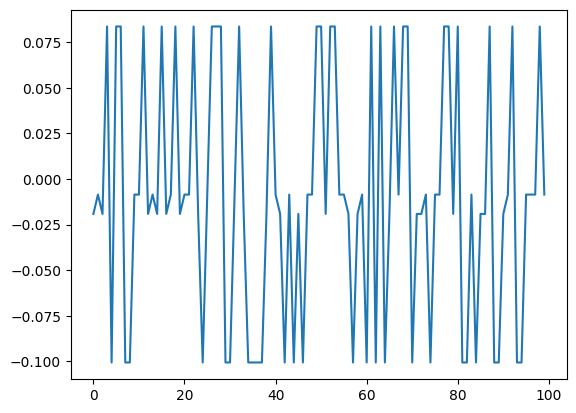

In [98]:
import re
out_vals = [float(re.match(r'v\(11\) - v\(1\) = (.*)', o).group(1)) for o in outs]
plt.plot(out_vals)

In [24]:
instance.reset()
print(instance.exec_command('rusage all'))

Total elapsed time (seconds) = 175632.209 
elapsed time since last call (seconds) = 5.280 
Total DRAM available = 16384.000 MB.
DRAM currently available =   58.094 MB.
Maximum ngspice program size = 0 bytes.
Current ngspice program size =  121.891 MB.
Number of lines in the deck = 25010
Netlist loading time = 0.002
Subckt and Param expansion time = 0.083
Netlist parsing time = 0.048
Nominal temperature = 27
Operating temperature = 27
Total iterations = 0
Transient iterations = 0
Circuit Equations = 7502
Circuit original non-zeroes = 0
Circuit fill-in non-zeroes = 0
Circuit total non-zeroes = 0
Transient timepoints = 0
Accepted timepoints = 0
Rejected timepoints = 0
Total analysis time (seconds) = 0
Matrix load time = 0
Matrix synchronize time = 0
Matrix reorder time = 0
Matrix factor time = 0
Matrix solve time = 0
Transient analysis time = 0
Transient load time = 0
Transient sync time = 0
Transient factor time = 0
Transient solve time = 0
Transient trunc time = 0
Transient iterations f

In [33]:
instance.reset()
instance.exec_command('option klu')
instance.run()
ru = instance.exec_command('rusage all')

Using KLU as Direct Linear Solver


In [34]:
ru = dict(line.split('=') for line in ru.split("\n"))
ru = {k.strip(): v.strip() for k, v in ru.items()}

In [35]:
ru

{'Total elapsed time (seconds)': '175859.241',
 'elapsed time since last call (seconds)': '226.303',
 'Total DRAM available': '16384.000 MB.',
 'DRAM currently available': '60.438 MB.',
 'Maximum ngspice program size': '0 bytes.',
 'Current ngspice program size': '142.594 MB.',
 'Number of lines in the deck': '25010',
 'Netlist loading time': '0.002',
 'Subckt and Param expansion time': '0.085',
 'Netlist parsing time': '0.052',
 'Nominal temperature': '27',
 'Operating temperature': '27',
 'Total iterations': '5',
 'Transient iterations': '0',
 'Circuit Equations': '12507',
 'Circuit original non-zeroes': '57514',
 'Circuit fill-in non-zeroes': '154141',
 'Circuit total non-zeroes': '211655',
 'Transient timepoints': '0',
 'Accepted timepoints': '0',
 'Rejected timepoints': '0',
 'Total analysis time (seconds)': '0.107',
 'Matrix load time': '0.013',
 'Matrix synchronize time': '0',
 'Matrix reorder time': '0.01',
 'Matrix factor time': '0.009',
 'Matrix solve time': '0.002',
 'Transi